# Neural Network

A Neural Network is a powerful supervised learning algorithm inspired by the structure of the human brain. It consists of interconnected layers of "neurons" that process data through a series of weighted transformations and non-linear activations.

In this project, we implemented a simple feedforward neural network (multi-layer perceptron) designed for binary classification structured as: 

 - Input Layer: Receives the data.

 - Hidden Layer: Contains a set of neurons applying a linear transformation followed by a non-linear activation function (Sigmoid or ReLU).

 - Output Layer: A single neuron with a sigmoid activation that outputs a probability between 0 and 1, representing the likelihood of the sample being in the positive class.
 
The principles behind the neural net are:

#### Forward Propagation

Each layer computes:

$z = xw + b$

Where:

X - input from the previous layer,

W - weights,

b - bias.

Then applies the activation function to produce the output layer A

#### Loss Calculation:

The network uses binary cross-entropy loss to measure how well its predictions align with the true values:

$\mathcal(L) = -\frac{1}{n} \sum_{i=1}^n (y_i \log(\hat{y}_i) + (1 - y_i)\log(1-\hat{y}_i))$

#### Bakcpropagation

The network uses the chain rule to compute gradients of the loss with respect to each weight and bias in the following way:

- Output layer: $dz = A - y$

- Hidden layer: $dz = (dA) × $activation derivative

These gradients are used to update weights and biases to reduce the loss.

#### Gradient Descent Optimization:

The weights and biases are updated iteratively using:

$ W := W − \alpha×dW$

Where $\alpha$ is the learning rate.

The neural network is a more sophisticated model, as it works for a number of data patterns, not just linearity. It is also customizable, with the possibility of changing factors such as depth, width and learning rate to better fit each type of dataset.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

We’ll use the Breast Cancer Wisconsin dataset from sklearn.datasets

This dataset contains information about tumors, including whether they are malignant or benign, based on various features extracted from cell nuclei.

For simplicity and visualization purposes, we’ll focus on just two features:

- Mean Radius

- Mean Texture

These features create a 2D feature space, where we can visually inspect how the neural network works on the data. While this choice limits visualization of the full predictive power of the dataset, it allows us to clearly observe the decision boundaries and interpret the classification results. 

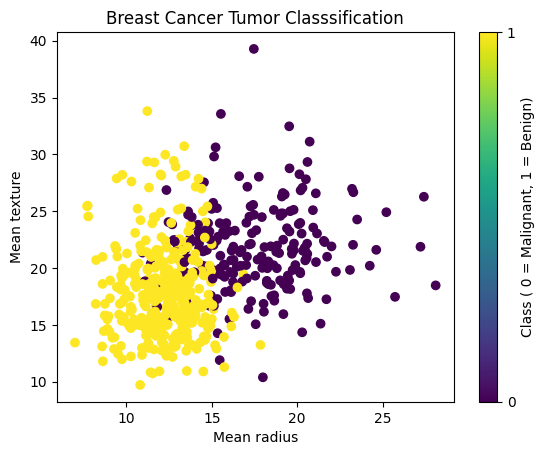

In [ ]:
#Loading data
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')  # Pick two features to plot
plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')

plt.show()

In [ ]:
class SimpleNeuralNetwork:
    def __init__(self, n_inputs, n_hidden=16, lr=0.01, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter

        # Xavier initialization
        limit1 = np.sqrt(6 / (n_inputs + n_hidden))
        limit2 = np.sqrt(6 / (n_hidden + 1))

        self.W1 = np.random.uniform(-limit1, limit1, (n_inputs, n_hidden))
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = np.random.uniform(-limit2, limit2, (n_hidden, 1))
        self.b2 = np.zeros((1, 1))
    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _sigmoid_derivative(self, a):
        return a * (1 - a)

    def _binary_cross_entropy(self, y_true, y_pred):
        m = y_true.shape[0]
        return -1 / m * np.sum(y_true * np.log(y_pred + 1e-15) + (1 - y_true) * np.log(1 - y_pred + 1e-15))

    def fit(self, X, y):
        m = X.shape[0]
        y = y.reshape(-1, 1)

        for _ in range(self.n_iter):
            # Forward pass
            Z1 = np.dot(X, self.W1) + self.b1
            A1 = self._sigmoid(Z1)
            Z2 = np.dot(A1, self.W2) + self.b2
            A2 = self._sigmoid(Z2)

            # Backpropagation
            dZ2 = A2 - y
            dW2 = np.dot(A1.T, dZ2) / m
            db2 = np.sum(dZ2, axis=0, keepdims=True) / m

            dA1 = np.dot(dZ2, self.W2.T)
            dZ1 = dA1 * self._sigmoid_derivative(A1)
            dW1 = np.dot(X.T, dZ1) / m
            db1 = np.sum(dZ1, axis=0, keepdims=True) / m

            # Update weights
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2

    def predict_prob(self, X):
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = self._sigmoid(Z1)
        Z2 = np.dot(A1, self.W2) + self.b2
        A2 = self._sigmoid(Z2)
        return A2

    def predict(self, X):
        A2 = self.predict_prob(X)
        return (A2 >= 0.5).astype(int).flatten()

In [ ]:
#Scalling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#Implement our neural network
nn = SimpleNeuralNetwork(n_inputs=X_train.shape[1], n_hidden=16, lr=0.01, n_iter=3000)
nn.fit(X_train, y_train)
y_pred_custom = nn.predict(X_test)
acc_nn = accuracy_score(y_test, y_pred_custom)
print(f"Custom Neural Network Accuracy: {acc_nn:.4f}")

Custom Neural Network Accuracy: 0.9912


In [ ]:
#Implement sklearn Neural Network
sklearn_nn = MLPClassifier(hidden_layer_sizes=(16,), max_iter=3000, random_state=42)
sklearn_nn.fit(X_train, y_train)
y_pred_sklearn = sklearn_nn.predict(X_test)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"Sklearn MLPClassifier Accuracy: {acc_sklearn:.4f}")

Sklearn MLPClassifier Accuracy: 0.9825


In [ ]:
#Comparing Results
print("\nComparison:")
print(f"Custom Neural Network correct: {(y_pred_custom == y_test).sum()} / {len(y_test)}")
print(f"Sklearn Neural Network correct: {(y_pred_sklearn == y_test).sum()} / {len(y_test)}")


Comparison:
Custom Decision Tree correct: 110 / 114
Sklearn Decision Tree correct: 112 / 114


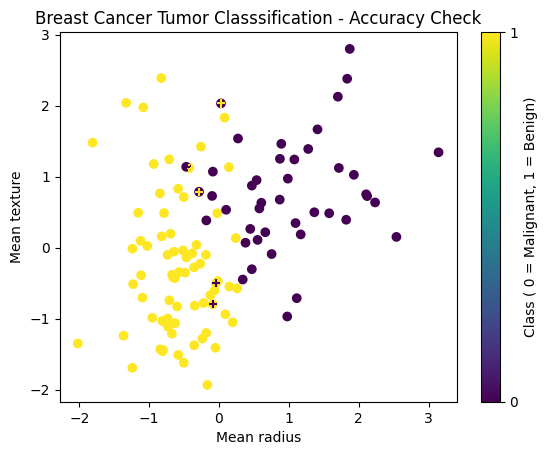

In [ ]:
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_pred_custom)
plt.scatter(X_test[:, 0], X_test[:, 1], c = y_test, marker = '+')

plt.xlabel('Mean radius')
plt.ylabel('Mean texture')
plt.title('Breast Cancer Tumor Classsification - Accuracy Check')

cbar = plt.colorbar()
cbar.set_ticks([0, 1])
cbar.set_label('Class ( 0 = Malignant, 1 = Benign)')

The performance of the neural network is truly remarkable! It beats all other supervised learning methods and is off by a single point in the dataset. Its accuracy improves when the number of repetitions increases, as expected, and our neural network actually even beats the sklearn implementation for $n \approx$ 3000 (of course that does not happen for every run, as is the nature of neural networks).

The initialization of the neural network is really important, and the initial weights can make or break the model. I have tried different initializations that would drop the accuracy to a 0.6, which is worse than a perceptron. It might be interesting to try some other options in the future and see how that impacts my neural network.